In [ ]:
import os, random, copy
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms, models
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)

import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from torch.amp import autocast, GradScaler

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

CSV_PATH = "/kaggle/input/octdl-for-image-based-deep-learning-methods/OCTDL_labels.csv"
IMAGE_ROOT = "/kaggle/input/octdl-for-image-based-deep-learning-methods/OCTDL/OCTDL"  # contains AMD, NO, DME, ...

Device: cuda


In [ ]:
df = pd.read_csv(CSV_PATH)

# disease folder is uppercase in your dataset (AMD, NO, DME, ERM, RVO, VID, RAO)
df["disease_folder"] = df["disease"].astype(str).str.upper().str.strip()

# file_name is a basename like amd_e_1.jpg; join: IMAGE_ROOT/<DISEASE>/<file_name>
df["path"] = df.apply(lambda r: os.path.join(IMAGE_ROOT, r["disease_folder"], str(r["file_name"]).strip()), axis=1)

df = df[df["path"].apply(os.path.exists)].reset_index(drop=True)

print("Resolved rows:", len(df))
print(df[["file_name","disease","subcategory","condition","path"]].head(10))
print("\nDisease counts:\n", df["disease_folder"].value_counts())

Resolved rows: 1618
       file_name disease subcategory condition  \
0    amd_e_1.jpg     AMD       early    drusen   
1   amd_e_10.jpg     AMD       early    drusen   
2  amd_e_100.jpg     AMD       early    drusen   
3  amd_e_101.jpg     AMD       early    drusen   
4  amd_e_102.jpg     AMD       early    drusen   
5  amd_e_103.jpg     AMD       early    drusen   
6  amd_e_104.jpg     AMD       early    drusen   
7  amd_e_105.jpg     AMD       early    drusen   
8  amd_e_106.jpg     AMD       early    drusen   
9  amd_e_107.jpg     AMD       early    drusen   

                                                path  
0  /kaggle/input/octdl-for-image-based-deep-learn...  
1  /kaggle/input/octdl-for-image-based-deep-learn...  
2  /kaggle/input/octdl-for-image-based-deep-learn...  
3  /kaggle/input/octdl-for-image-based-deep-learn...  
4  /kaggle/input/octdl-for-image-based-deep-learn...  
5  /kaggle/input/octdl-for-image-based-deep-learn...  
6  /kaggle/input/octdl-for-image-based-deep-

In [ ]:
# Task 1: AMD detection (binary)
df_det = df.copy()
df_det["y_det"] = (df_det["disease_folder"] == "AMD").astype(int)
det_class_names = ["Not-AMD", "AMD"]
print("AMD detection label counts:\n", df_det["y_det"].value_counts())

# Task 2: AMD staging (3-class) from subcategory (only AMD rows)
df_stage = df[df["disease_folder"] == "AMD"].copy()
df_stage["subcategory_norm"] = df_stage["subcategory"].astype(str).str.strip().str.lower()

stage_map = {"early": 0, "intermediate": 1, "late": 2}
df_stage = df_stage[df_stage["subcategory_norm"].isin(stage_map)].copy()
df_stage["y_stage"] = df_stage["subcategory_norm"].map(stage_map).astype(int)

stage_names = ["Early", "Intermediate", "Late"]
print("AMD staging label counts:\n", df_stage["y_stage"].value_counts().sort_index())
print("Unique AMD conditions:\n", df_stage["condition"].dropna().unique())

AMD detection label counts:
 y_det
1    885
0    733
Name: count, dtype: int64
AMD staging label counts:
 y_stage
0    192
1    175
2    518
Name: count, dtype: int64
Unique AMD conditions:
 ['drusen' 'MNV' 'MNV_suspected']


In [ ]:
class CSVOCTDataset(Dataset):
    def __init__(self, df, path_col, label_col, transform=None):
        self.df = df.reset_index(drop=True)
        self.path_col = path_col
        self.label_col = label_col
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        p = self.df.loc[idx, self.path_col]
        y = int(self.df.loc[idx, self.label_col])
        img = Image.open(p).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, y


class AddGaussianNoise(nn.Module):
    def __init__(self, std=0.01, p=0.15):
        super().__init__()
        self.std = std
        self.p = p
    def forward(self, x):
        if torch.rand(1).item() < self.p:
            x = torch.clamp(x + torch.randn_like(x) * self.std, 0.0, 1.0)
        return x


def make_transforms(img_size):
    train_tfms = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomResizedCrop(img_size, scale=(0.92, 1.0)),
        transforms.RandomRotation(5),
        transforms.ToTensor(),
        AddGaussianNoise(std=0.01, p=0.15),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    ])
    eval_tfms = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    ])
    return train_tfms, eval_tfms

In [ ]:
def build_model(model_name, num_classes):
    if model_name == "resnet50":
        m = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        m.fc = nn.Linear(m.fc.in_features, num_classes)
        return m

    if model_name == "efficientnet_b4":
        m = models.efficientnet_b4(weights=models.EfficientNet_B4_Weights.IMAGENET1K_V1)
        in_features = m.classifier[1].in_features
        m.classifier[1] = nn.Linear(in_features, num_classes)
        return m

    raise ValueError("Unknown model_name")

In [ ]:
def split_df(df_in, label_col, seed=SEED):
    df_train, df_temp = train_test_split(
        df_in, test_size=0.30, random_state=seed, stratify=df_in[label_col]
    )
    df_val, df_test = train_test_split(
        df_temp, test_size=0.50, random_state=seed, stratify=df_temp[label_col]
    )
    return df_train.reset_index(drop=True), df_val.reset_index(drop=True), df_test.reset_index(drop=True)

def make_sampler(labels, num_classes):
    labels = np.asarray(labels)
    class_count = np.bincount(labels, minlength=num_classes)
    class_weights = 1.0 / (class_count + 1e-6)
    sample_weights = class_weights[labels]
    sampler = WeightedRandomSampler(
        torch.tensor(sample_weights, dtype=torch.double),
        num_samples=len(sample_weights),
        replacement=True
    )
    return sampler, class_count

def sanitize_probs(probs, eps=1e-12):
    """
    Make probs finite and ensure each row sums to 1.
    Required for sklearn multiclass roc_auc_score.
    """
    probs = np.asarray(probs, dtype=np.float64)
    probs = np.nan_to_num(probs, nan=0.0, posinf=0.0, neginf=0.0)
    probs = np.clip(probs, eps, 1.0)
    s = probs.sum(axis=1, keepdims=True)
    s = np.where(s <= 0, 1.0, s)
    return probs / s

In [ ]:
def run_task(model_name, df_task, label_col, class_names, img_size, batch_size,
             epochs=15, freeze_epochs=2):

    print("\n" + "#"*90)
    print(f"MODEL={model_name} | TASK={label_col} | classes={class_names}")
    print("#"*90)

    train_tfms, eval_tfms = make_transforms(img_size)
    df_tr, df_va, df_te = split_df(df_task, label_col)

    ds_tr = CSVOCTDataset(df_tr, "path", label_col, transform=train_tfms)
    ds_va = CSVOCTDataset(df_va, "path", label_col, transform=eval_tfms)
    ds_te = CSVOCTDataset(df_te, "path", label_col, transform=eval_tfms)

    num_classes = len(class_names)
    sampler, class_count = make_sampler(df_tr[label_col].values, num_classes)

    print("Train class counts:", dict(zip(range(num_classes), class_count.tolist())))

    train_loader = DataLoader(ds_tr, batch_size=batch_size, sampler=sampler, num_workers=0, pin_memory=True)
    val_loader   = DataLoader(ds_va, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)
    test_loader  = DataLoader(ds_te, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

    model = build_model(model_name, num_classes).to(device)

    # freeze backbone
    for p in model.parameters():
        p.requires_grad = False
    if model_name == "resnet50":
        for p in model.fc.parameters():
            p.requires_grad = True
    else:
        for p in model.classifier.parameters():
            p.requires_grad = True

    criterion = nn.CrossEntropyLoss()

    # AMP policy
    use_amp = (device.type == "cuda") and (model_name == "resnet50")
    scaler = GradScaler(enabled=use_amp)


    # LRs
    if label_col == "y_stage":
        # staging = harder; use smaller fine-tune LR
        if model_name == "resnet50":
            head_lr, ft_lr = 1e-3, 1e-4
        else:  # efficientnet_b4
            head_lr, ft_lr = 3e-4, 5e-5
    else:
        # detection (binary) = easier; your original LRs are fine
        if model_name == "resnet50":
            head_lr, ft_lr = 1e-3, 2e-4
        else:
            head_lr, ft_lr = 3e-4, 1e-4

    def make_opt(lr):
        return torch.optim.AdamW(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=lr, weight_decay=1e-4
        )

    optimizer = make_opt(head_lr)

    best_state = copy.deepcopy(model.state_dict())
    best_val = float("inf")
    train_losses, val_losses = [], []

    for ep in range(1, epochs + 1):
        if ep == freeze_epochs + 1:
            for p in model.parameters():
                p.requires_grad = True
            optimizer = make_opt(ft_lr)
            print(f"Unfroze all layers. Fine-tune LR={ft_lr}")

        # Train
        model.train()
        tr_sum, tr_n = 0.0, 0
        for x, y in tqdm(train_loader, leave=False):
            x = x.to(device); y = y.to(device)
            optimizer.zero_grad(set_to_none=True)

            with autocast(device_type="cuda", enabled=use_amp):
                logits = model(x)
                loss = criterion(logits, y)

            if use_amp:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            tr_sum += loss.item() * x.size(0)
            tr_n += x.size(0)

        tr_loss = tr_sum / tr_n

        # Validate
        model.eval()
        va_sum, va_n = 0.0, 0
        with torch.no_grad():
            for x, y in tqdm(val_loader, leave=False):
                x = x.to(device); y = y.to(device)
                with autocast(device_type="cuda", enabled=use_amp):
                    logits = model(x)
                    loss = criterion(logits, y)
                va_sum += loss.item() * x.size(0)
                va_n += x.size(0)

        va_loss = va_sum / va_n
        train_losses.append(tr_loss)
        val_losses.append(va_loss)

        print(f"Epoch {ep:02d}/{epochs} | train {tr_loss:.4f} | val {va_loss:.4f}")

        if va_loss < best_val:
            best_val = va_loss
            best_state = copy.deepcopy(model.state_dict())

    # Test inference
    model.load_state_dict(best_state)
    model.eval()

    y_true, y_pred, probs = [], [], []
    with torch.no_grad():
        for x, y in tqdm(test_loader, leave=False):
            x = x.to(device)
            with autocast(device_type="cuda", enabled=use_amp):
                logits = model(x)
            p = torch.softmax(logits, dim=1).cpu().numpy()
            probs.append(p)
            y_true.append(y.numpy())
            y_pred.append(p.argmax(axis=1))

    probs = np.vstack(probs)
    probs = sanitize_probs(probs)
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)

    # Loss curves
    plt.figure(figsize=(7,5))
    plt.plot(train_losses, label="Train loss")
    plt.plot(val_losses, label="Val loss")
    plt.title(f"Loss Curves - {model_name} ({label_col})")
    plt.xlabel("Epoch"); plt.ylabel("Loss")
    plt.grid(True); plt.legend()
    plt.show()

    # Classification report
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4, zero_division=0))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f"Confusion Matrix - {model_name} ({label_col})")
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    # ROC/AUC
    if num_classes == 2:
        auc_val = roc_auc_score(y_true, probs[:, 1])
        fpr, tpr, _ = roc_curve(y_true, probs[:, 1])

        plt.figure(figsize=(6,5))
        plt.plot(fpr, tpr, label=f"AUC={auc_val:.4f}")
        plt.plot([0,1],[0,1],"k--")
        plt.title(f"ROC - {model_name} ({label_col})")
        plt.xlabel("FPR"); plt.ylabel("TPR")
        plt.legend(); plt.grid(True)
        plt.show()

        print("AUC:", auc_val)
    else:
        auc_macro = roc_auc_score(y_true, probs, multi_class="ovr", average="macro")
        auc_weighted = roc_auc_score(y_true, probs, multi_class="ovr", average="weighted")
        print("AUC macro OvR:", auc_macro)
        print("AUC weighted OvR:", auc_weighted)

    return {"y_true": y_true, "y_pred": y_pred, "probs": probs}

==== ResNet50: AMD DETECTION (AMD vs Not-AMD) ====

##########################################################################################
MODEL=resnet50 | TASK=y_det | classes=['Not-AMD', 'AMD']
##########################################################################################
Train class counts: {0: 513, 1: 619}


Epoch 01/15 | train 0.5821 | val 0.5664


Epoch 02/15 | train 0.4933 | val 0.4814
Unfroze all layers. Fine-tune LR=0.0002


Epoch 03/15 | train 0.2789 | val 0.3140


Epoch 04/15 | train 0.1485 | val 0.1767


...

Epoch 11/15 | train 0.0539 | val 0.1968


Epoch 12/15 | train 0.0265 | val 0.4289


Epoch 13/15 | train 0.0163 | val 0.2808


Epoch 14/15 | train 0.0225 | val 0.3445


Epoch 15/15 | train 0.0486 | val 0.3467


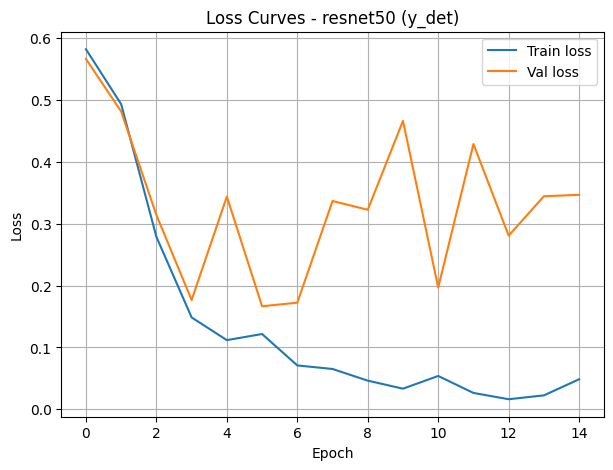


Classification Report:
              precision    recall  f1-score   support

     Not-AMD     0.9554    0.9727    0.9640       110
         AMD     0.9771    0.9624    0.9697       133

    accuracy                         0.9671       243
   macro avg     0.9662    0.9676    0.9668       243
weighted avg     0.9673    0.9671    0.9671       243



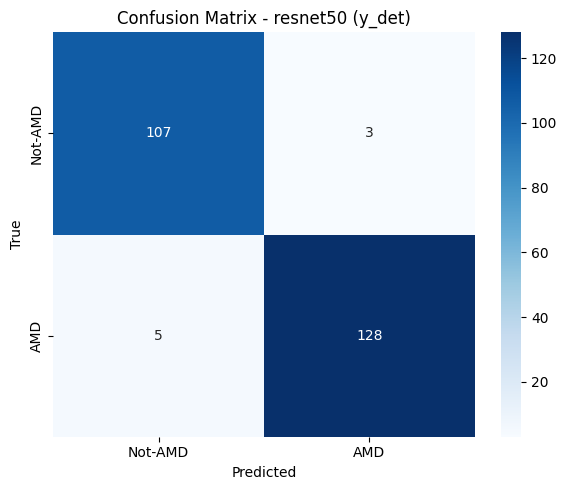

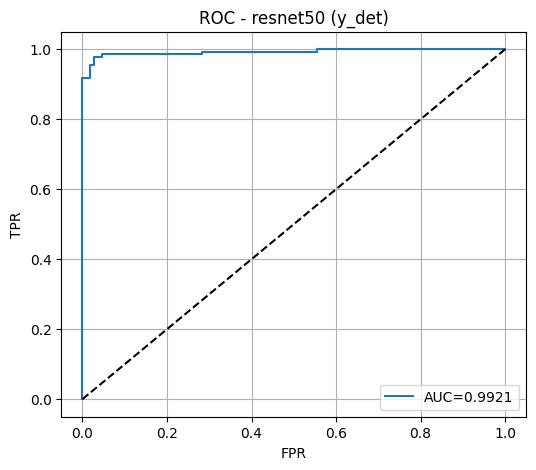

AUC: 0.992071086807929
==== EfficientNet-B4: AMD DETECTION (AMD vs Not-AMD) ====

##########################################################################################
MODEL=efficientnet_b4 | TASK=y_det | classes=['Not-AMD', 'AMD']
##########################################################################################
Train class counts: {0: 513, 1: 619}


Epoch 01/15 | train 0.6525 | val 0.6164


Epoch 02/15 | train 0.5964 | val 0.5816
Unfroze all layers. Fine-tune LR=0.0001


Epoch 03/15 | train 0.4185 | val 0.2939


Epoch 04/15 | train 0.2499 | val 0.2675


...

Epoch 11/15 | train 0.0737 | val 0.1466


Epoch 12/15 | train 0.0470 | val 0.2038


Epoch 13/15 | train 0.0389 | val 0.1435


Epoch 14/15 | train 0.0374 | val 0.1007


Epoch 15/15 | train 0.0472 | val 0.1192


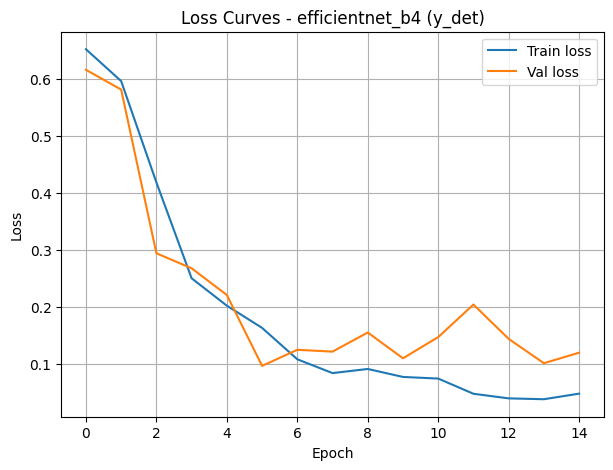


Classification Report:
              precision    recall  f1-score   support

     Not-AMD     0.9464    0.9636    0.9550       110
         AMD     0.9695    0.9549    0.9621       133

    accuracy                         0.9588       243
   macro avg     0.9579    0.9593    0.9585       243
weighted avg     0.9590    0.9588    0.9589       243



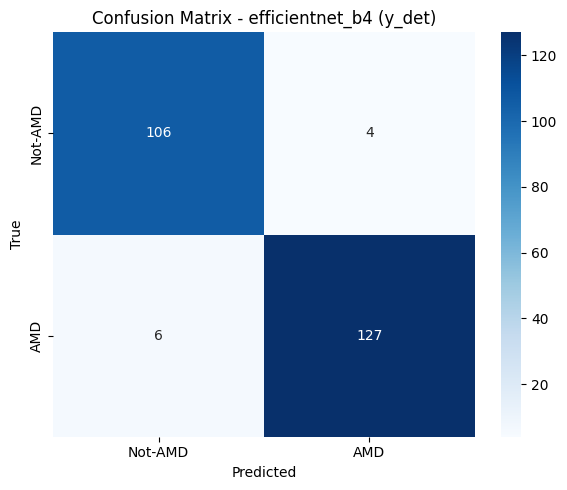

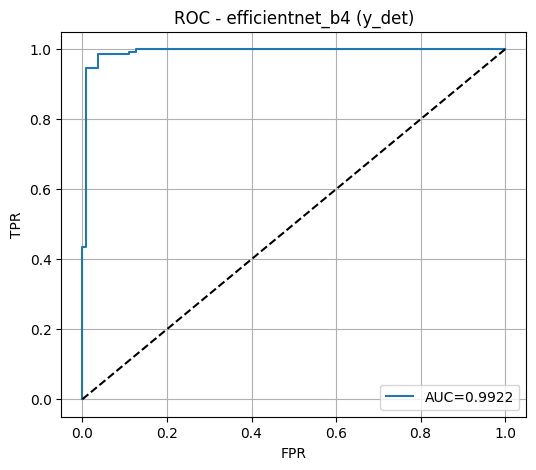

AUC: 0.9922077922077923


In [ ]:
print("==== ResNet50: AMD DETECTION (AMD vs Not-AMD) ====")
resnet_det = run_task(
    model_name="resnet50",
    df_task=df_det,
    label_col="y_det",
    class_names=det_class_names,
    img_size=224,
    batch_size=32,
    epochs=15,
    freeze_epochs=2
)

print("==== EfficientNet-B4: AMD DETECTION (AMD vs Not-AMD) ====")
effb4_det = run_task(
    model_name="efficientnet_b4",
    df_task=df_det,
    label_col="y_det",
    class_names=det_class_names,
    img_size=380,
    batch_size=8,
    epochs=15,
    freeze_epochs=2
)

==== ResNet50: AMD STAGING (Early/Intermediate/Late) ====

##########################################################################################
MODEL=resnet50 | TASK=y_stage | classes=['Early', 'Intermediate', 'Late']
##########################################################################################
Train class counts: {0: 134, 1: 123, 2: 362}


Epoch 01/15 | train 1.0544 | val 1.0031


Epoch 02/15 | train 0.9526 | val 0.9252
Unfroze all layers. Fine-tune LR=0.0001


Epoch 03/15 | train 0.7486 | val 0.6062


Epoch 04/15 | train 0.4154 | val 0.6030


...

Epoch 11/15 | train 0.0699 | val 0.4809


Epoch 12/15 | train 0.0632 | val 0.4121


Epoch 13/15 | train 0.1076 | val 0.8574


Epoch 14/15 | train 0.0542 | val 0.6386


Epoch 15/15 | train 0.0469 | val 0.6127


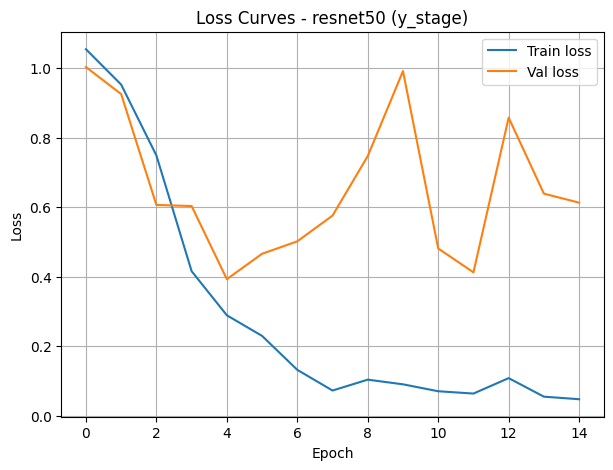


Classification Report:
              precision    recall  f1-score   support

       Early     0.6486    0.8276    0.7273        29
Intermediate     0.5000    0.3077    0.3810        26
        Late     0.9000    0.9231    0.9114        78

    accuracy                         0.7820       133
   macro avg     0.6829    0.6861    0.6732       133
weighted avg     0.7670    0.7820    0.7676       133



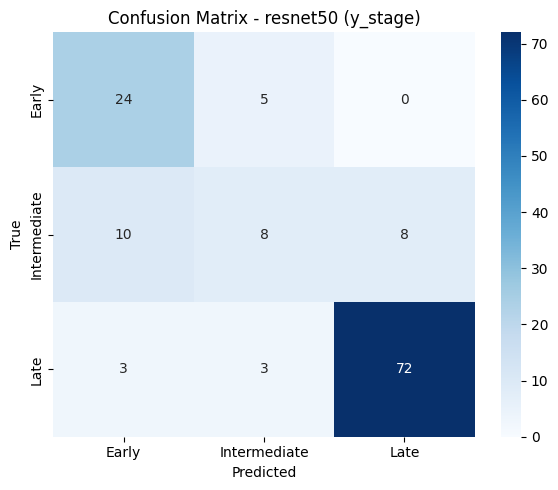

AUC macro OvR: 0.9124966852891442
AUC weighted OvR: 0.9275939628497426
==== EfficientNet-B4: AMD STAGING (Early/Intermediate/Late) ====

##########################################################################################
MODEL=efficientnet_b4 | TASK=y_stage | classes=['Early', 'Intermediate', 'Late']
##########################################################################################
Train class counts: {0: 134, 1: 123, 2: 362}


Epoch 01/15 | train 1.0796 | val 1.0625


Epoch 02/15 | train 1.0410 | val 1.0229
Unfroze all layers. Fine-tune LR=5e-05


Epoch 03/15 | train 0.9757 | val 0.9175


Epoch 04/15 | train 0.8418 | val 0.7470


...

Epoch 11/15 | train 0.3597 | val 0.4243


Epoch 12/15 | train 0.3164 | val 0.4060


Epoch 13/15 | train 0.3175 | val 0.4280


Epoch 14/15 | train 0.2493 | val 0.4175


Epoch 15/15 | train 0.2043 | val 0.4815


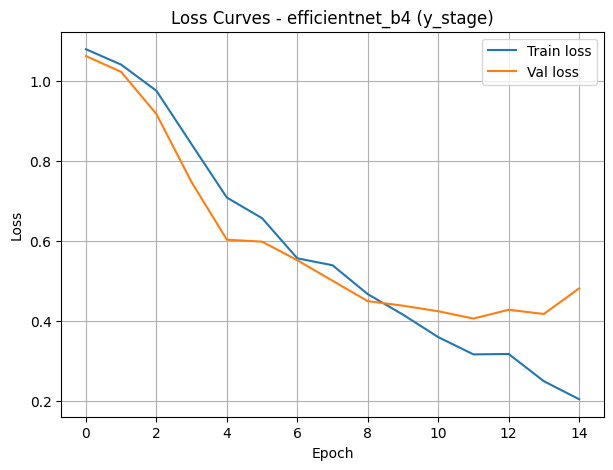


Classification Report:
              precision    recall  f1-score   support

       Early     0.7143    0.8621    0.7813        29
Intermediate     0.5429    0.7308    0.6230        26
        Late     0.9683    0.7821    0.8652        78

    accuracy                         0.7895       133
   macro avg     0.7418    0.7916    0.7565       133
weighted avg     0.8297    0.7895    0.7996       133



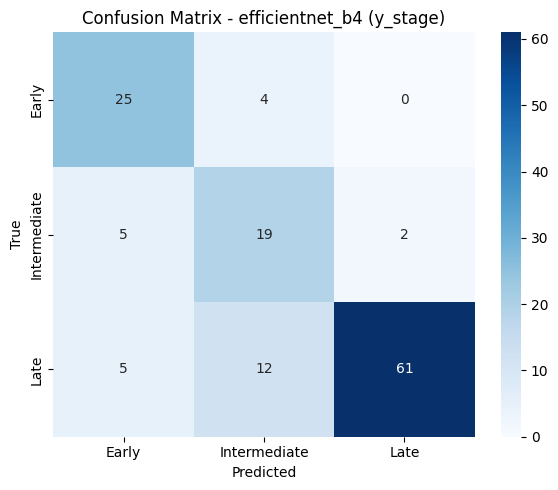

AUC macro OvR: 0.9078264110652122
AUC weighted OvR: 0.9290860885302596


In [ ]:
print("==== ResNet50: AMD STAGING (Early/Intermediate/Late) ====")
resnet_stage = run_task(
    model_name="resnet50",
    df_task=df_stage,
    label_col="y_stage",
    class_names=stage_names,
    img_size=224,
    batch_size=32,
    epochs=15,
    freeze_epochs=2
)

print("==== EfficientNet-B4: AMD STAGING (Early/Intermediate/Late) ====")
effb4_stage = run_task(
    model_name="efficientnet_b4",
    df_task=df_stage,
    label_col="y_stage",
    class_names=stage_names,
    img_size=380,
    batch_size=8,
    epochs=15,
    freeze_epochs=2
)

In [ ]:
import numpy as np
from sklearn.metrics import (
    confusion_matrix, roc_auc_score,
    f1_score
)
from sklearn.preprocessing import label_binarize

def binary_metrics_amd_detection(y_true, y_pred, prob_pos):
    """
    y_true: 0/1 (0=Not-AMD, 1=AMD)
    prob_pos: P(AMD) probability array shape [N]
    """
    cm = confusion_matrix(y_true, y_pred, labels=[0,1])
    tn, fp, fn, tp = cm.ravel()

    acc = (tp + tn) / (tp + tn + fp + fn + 1e-12)

    sensitivity = tp / (tp + fn + 1e-12)  # Recall(AMD)
    specificity = tn / (tn + fp + 1e-12)  # Recall(Not-AMD)

    auc_val = roc_auc_score(y_true, prob_pos)

    return {
        "accuracy": acc,
        "sensitivity_recall_AMD": sensitivity,
        "specificity": specificity,
        "auc": auc_val,
        "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)
    }

def staging_metrics(y_true, y_pred, probs, class_names):
    """
    3-class (Early/Intermediate/Late).
    Returns macro/weighted F1, macro AUC (OvR) and per-class AUC.
    """
    probs = np.asarray(probs, dtype=np.float64)

    f1_macro = f1_score(y_true, y_pred, average="macro")
    f1_weighted = f1_score(y_true, y_pred, average="weighted")

    # macro AUC OvR
    auc_macro = roc_auc_score(y_true, probs, multi_class="ovr", average="macro")

    # per-stage AUC (OvR for each class)
    n = len(class_names)
    y_bin = label_binarize(y_true, classes=list(range(n)))
    per_stage_auc = {}
    for i, name in enumerate(class_names):
        # if a class is missing in y_true, roc_auc_score will error; guard it
        if y_bin[:, i].sum() == 0 or y_bin[:, i].sum() == len(y_bin):
            per_stage_auc[name] = np.nan
        else:
            per_stage_auc[name] = roc_auc_score(y_bin[:, i], probs[:, i])

    return {
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "auc_macro_ovr": auc_macro,
        "per_stage_auc": per_stage_auc
    }

In [ ]:
import pandas as pd

# ---- AMD Detection summary ----
det_rows = []

for model_name, out in [
    ("ResNet50", resnet_det),
    ("EfficientNet-B4", effb4_det),
]:
    y_true = out["y_true"]
    y_pred = out["y_pred"]
    prob_amd = out["probs"][:, 1]  # AMD is class index 1

    m = binary_metrics_amd_detection(y_true, y_pred, prob_amd)
    det_rows.append({
        "model": model_name,
        "accuracy": m["accuracy"],
        "sensitivity(Recall AMD)": m["sensitivity_recall_AMD"],
        "specificity": m["specificity"],
        "AUC": m["auc"],
        "TN": m["tn"], "FP": m["fp"], "FN": m["fn"], "TP": m["tp"]
    })

det_summary = pd.DataFrame(det_rows)
display(det_summary)


# ---- AMD Staging summary ----
stage_rows = []

for model_name, out in [
    ("ResNet50", resnet_stage),
    ("EfficientNet-B4", effb4_stage),
]:
    y_true = out["y_true"]
    y_pred = out["y_pred"]
    probs  = out["probs"]  # shape [N,3]

    m = staging_metrics(y_true, y_pred, probs, stage_names)

    row = {
        "model": model_name,
        "Macro F1": m["f1_macro"],
        "Weighted F1": m["f1_weighted"],
        "Macro AUC (OvR)": m["auc_macro_ovr"],
    }
    # add per-stage AUC columns
    for k, v in m["per_stage_auc"].items():
        row[f"AUC {k} (OvR)"] = v

    stage_rows.append(row)

stage_summary = pd.DataFrame(stage_rows)
display(stage_summary)

,model,accuracy,sensitivity(Recall AMD),specificity,AUC,TN,FP,FN,TP
0,ResNet50,0.967078,0.962406,0.972727,0.992071,107,3,5,128
1,EfficientNet-B4,0.958848,0.954887,0.963636,0.992208,106,4,6,127


,model,Macro F1,Weighted F1,Macro AUC (OvR),AUC Early (OvR),AUC Intermediate (OvR),AUC Late (OvR)
0,ResNet50,0.673206,0.767551,0.912497,0.949934,0.838605,0.948951
1,EfficientNet-B4,0.756483,0.799566,0.907826,0.947613,0.815960,0.959907
